# CGS 410 — Decoding the Temporal and Topological Fingerprints of Human Language

**Author:** Tushar Bagani (241108)  

---

## Step 1: Extract Dependency Tree Structures from SUD Corpus

This section follows the tree-building approach from the **DLM-ICM-baselines** codebase  
([yadavhimanshu059/DLM-ICM-baselines](https://github.com/yadavhimanshu059/DLM-ICM-baselines)).  

Each sentence is parsed from CoNLL-U format into a **`networkx.DiGraph`** where:
- **Nodes** carry attributes: `form`, `lemma`, `upostag`, `xpostag`, `feats`, `head`, `deprel`, `deps`, `misc`
- **Edges** go from head → dependent with the label `drel`
- A virtual **ROOT node (id = 0)** is added as the ancestor of the syntactic root
- **Punctuation tokens** (`deprel == 'punct'`) are excluded (same as the reference code)
- Only sentences with **fewer than 12 edges** (i.e. < 12 non-punct words) are kept

In [47]:
import os
import random
import copy
from io import open
from typing import List, Dict, Tuple, Optional

import networkx as nx
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from conllu import parse

### 1.1  Build a dependency tree from a single CoNLL-U sentence

This function mirrors the tree construction logic from  
`construct_output_random_structures.py` in the DLM-ICM-baselines repo.

In [48]:
def build_tree_from_sentence(sentence) -> nx.DiGraph:
    """
    Convert one parsed CoNLL-U sentence (from the `conllu` library) into a
    networkx DiGraph, following the DLM-ICM-baselines approach:

      1.  Each non-punctuation token becomes a node with attributes
          (form, lemma, upostag, xpostag, feats, head, deprel, deps, misc).
      2.  A virtual ROOT node (id = 0) is added.
      3.  Directed edges go from head → dependent.
      4.  Punctuation tokens (deprel == 'punct') are excluded.
    """
    tree = nx.DiGraph()

    for token in sentence:
        # Skip multi-word tokens (id is a tuple/range) and empty nodes
        if not isinstance(token['id'], int):
            continue

        deprel = token['deprel']

        # ── Exclude punctuation (same as reference code) ──
        if deprel == 'punct':
            continue

        tree.add_node(
            token['id'],
            form    = token['form'],
            lemma   = token.get('lemma', '_'),
            upostag = token.get('upos', '_'),
            xpostag = token.get('xpos', '_'),
            feats   = token.get('feats', '_'),
            head    = token['head'] if token['head'] is not None else 0,
            deprel  = deprel,
            deps    = token.get('deps', '_'),
            misc    = token.get('misc', '_'),
        )

    # ── Add virtual ROOT (id = 0) ──
    ROOT = 0
    tree.add_node(ROOT)

    # ── Create directed edges (head → dependent) ──
    for nodex in list(tree.nodes):
        if nodex != ROOT:
            head_id = tree.nodes[nodex]['head']
            if tree.has_node(head_id):                    # handle disjoint trees
                tree.add_edge(
                    head_id,
                    nodex,
                    drel=tree.nodes[nodex]['deprel'],
                )

    return tree

### 1.2  Parse a CoNLL-U file and filter sentences

Following the reference code's condition `if n < 12 and n > 1`  
where `n = len(tree.edges)`, we keep only sentences whose tree has  
**fewer than 12 edges** and **more than 1 edge**.

In [49]:
MAX_EDGES = 12   # exclusive upper bound (n < 12)


def parse_conllu_file(filepath: str,
                      max_edges: int = MAX_EDGES
                      ) -> List[Dict]:
    """
    Read a .conllu file and return a list of dicts, each containing:
        - 'tree'    : nx.DiGraph  (the dependency tree)
        - 'sent_id' : int
        - 'text'    : str         (original sentence text if available)
        - 'n_edges' : int         (number of edges, excl. punct)

    Only sentences with  1 < n_edges < max_edges  are kept.
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        data = f.read()

    sentences = parse(data)
    results: List[Dict] = []

    for idx, sentence in enumerate(sentences, start=1):
        tree = build_tree_from_sentence(sentence)
        n = len(tree.edges)

        if n < max_edges and n > 1:
            text = sentence.metadata.get('text', '') if sentence.metadata else ''
            results.append({
                'tree'   : tree,
                'sent_id': idx,
                'text'   : text,
                'n_edges': n,
            })

    return results


def parse_all_conllu_in_dir(directory: str,
                            max_edges: int = MAX_EDGES
                            ) -> Dict[str, List[Dict]]:
    """
    Walk a directory, find every .conllu file, parse and filter them.

    Returns
    -------
    dict :  { filepath : [ {tree, sent_id, text, n_edges}, … ] }
    """
    corpus: Dict[str, List[Dict]] = {}
    for root, _dirs, files in os.walk(directory):
        for fname in sorted(files):
            if fname.endswith('.conllu'):
                fpath = os.path.join(root, fname)
                trees = parse_conllu_file(fpath, max_edges)
                corpus[fpath] = trees

                # ── Extract language name from filename ──
                lang = fname.replace('_train.conllu', '')
                lang = lang.replace('_test.conllu', '')
                lang = lang.replace('.conllu', '')

                print(f"  ✓ {lang:<20s}  ({fname})  →  {len(trees)} sentences  (edges < {max_edges})")
    return corpus

### 1.3  Load the corpus

All language `.conllu` files are in the `train/` folder.

In [50]:
# ── Parse all .conllu files in the train directory ──
CORPUS_DIR = r"train"   # folder containing all language .conllu files

print(f"Scanning: {os.path.abspath(CORPUS_DIR)}\n")
corpus = parse_all_conllu_in_dir(CORPUS_DIR)

# Flatten into a single list
all_records = [rec for recs in corpus.values() for rec in recs]
print(f"\n── Total sentences loaded (1 < edges < {MAX_EDGES}): {len(all_records)}")

Scanning: c:\Users\tusha\OneDrive\Documents\CGS_Project\train

  ✓ english               (english_train.conllu)  →  4982 sentences  (edges < 12)

── Total sentences loaded (1 < edges < 12): 4982


### 1.4  Inspect the extracted trees

Each tree is a `networkx.DiGraph` with node/edge attributes identical  
to those produced by the DLM-ICM-baselines code.

In [51]:
def print_tree_recursive(tree: nx.DiGraph, node: int = 0, indent: int = 0):
    """Pretty-print the tree from a given node downwards."""
    if node == 0:
        label = 'ROOT'
    else:
        attrs = tree.nodes[node]
        label = f"{attrs.get('form', '?')}  [{attrs.get('upostag', '?')}]  ──{attrs.get('deprel', '?')}──"
    print(' ' * indent + label)
    for child in sorted(tree.successors(node)):
        print_tree_recursive(tree, child, indent + 4)


# Show first 5 sentences
for i, rec in enumerate(all_records[:5]):
    tree = rec['tree']
    print(f"\n{'='*70}")
    print(f"Sentence {rec['sent_id']}  |  Edges: {rec['n_edges']}")
    print(f"Text: {rec['text']}")
    print(f"\nNodes:")
    for nid in sorted(tree.nodes):
        if nid == 0:
            print(f"  [0] ROOT")
        else:
            a = tree.nodes[nid]
            print(f"  [{nid}] {a.get('form','?'):<15s}  POS={a.get('upostag','?'):<6s}  head={a.get('head','?')}  deprel={a.get('deprel','?')}")
    print(f"\nEdges (head → dep):")
    for h, d, data in tree.edges(data=True):
        print(f"  {h} → {d}   ({data.get('drel', '?')})")
    print('-'*70)
    print_tree_recursive(tree)


Sentence 18  |  Edges: 8
Text: Guerrillas killed an engineer, Asi Ali, from Tikrit.

Nodes:
  [0] ROOT
  [1] Guerrillas       POS=NOUN    head=2  deprel=subj
  [2] killed           POS=VERB    head=0  deprel=root
  [3] an               POS=DET     head=4  deprel=det
  [4] engineer         POS=NOUN    head=2  deprel=comp:obj
  [6] Asi              POS=PROPN   head=4  deprel=conj:appos
  [7] Ali              POS=PROPN   head=6  deprel=flat
  [9] from             POS=ADP     head=4  deprel=udep
  [10] Tikrit           POS=PROPN   head=9  deprel=comp:obj

Edges (head → dep):
  2 → 1   (subj)
  2 → 4   (comp:obj)
  4 → 3   (det)
  4 → 6   (conj:appos)
  4 → 9   (udep)
  6 → 7   (flat)
  9 → 10   (comp:obj)
  0 → 2   (root)
----------------------------------------------------------------------
ROOT
    killed  [VERB]  ──root──
        Guerrillas  [NOUN]  ──subj──
        engineer  [NOUN]  ──comp:obj──
            an  [DET]  ──det──
            Asi  [PROPN]  ──conj:appos──
                Al

### 1.5  Visualise a dependency tree

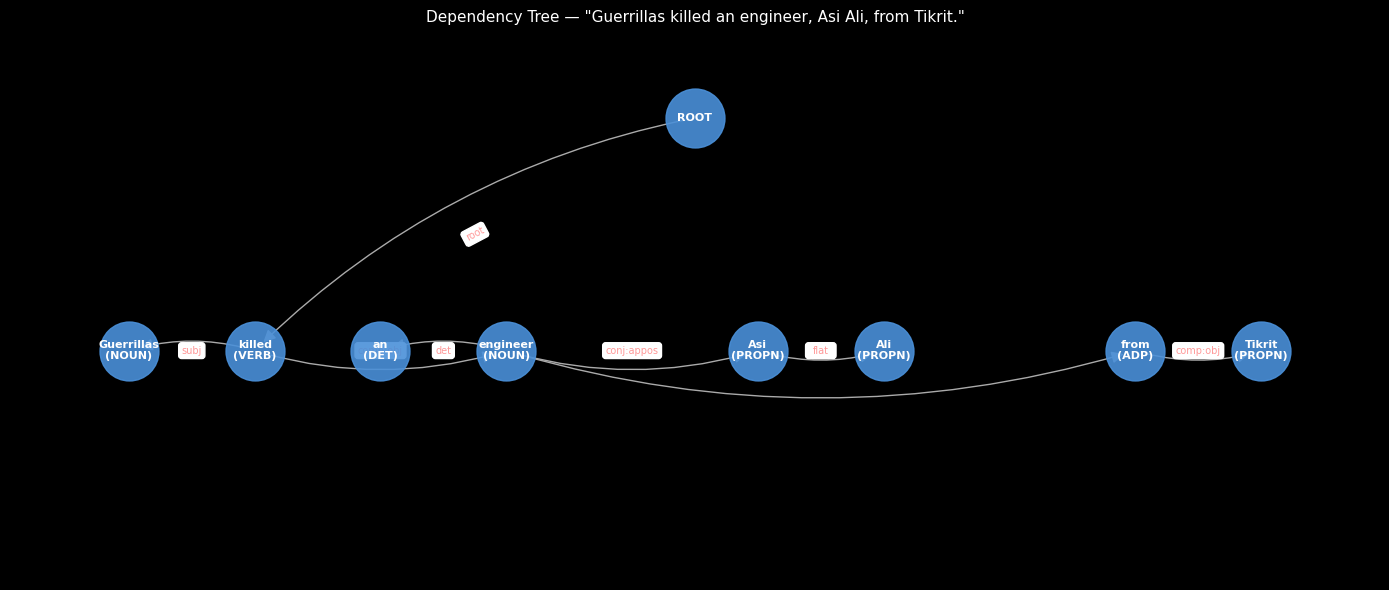

In [52]:
def plot_dependency_tree(rec: Dict, figsize: Tuple = (14, 6)):
    """
    Draw a dependency tree using NetworkX + Matplotlib.
    Words are laid out left-to-right in sentence order; ROOT sits above.
    """
    tree = rec['tree']
    non_root_nodes = sorted(n for n in tree.nodes if n != 0)

    # ── Position: ROOT at top-center, words along x-axis ──
    pos = {}
    if non_root_nodes:
        mid = (non_root_nodes[0] + non_root_nodes[-1]) / 2
    else:
        mid = 0
    pos[0] = (mid, 1)   # ROOT above
    for n in non_root_nodes:
        pos[n] = (n, 0)

    # ── Labels ──
    labels = {0: 'ROOT'}
    for n in non_root_nodes:
        a = tree.nodes[n]
        labels[n] = f"{a.get('form','?')}\n({a.get('upostag','?')})"

    # ── Edge labels ──
    edge_labels = {(h, d): data.get('drel', '')
                   for h, d, data in tree.edges(data=True)}

    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_nodes(tree, pos,
                           node_color='#4A90D9', node_size=1800,
                           alpha=0.9, ax=ax)
    nx.draw_networkx_labels(tree, pos, labels,
                            font_size=8, font_weight='bold',
                            font_color='white', ax=ax)
    nx.draw_networkx_edges(tree, pos,
                           edge_color='#AAAAAA', arrows=True,
                           arrowsize=18,
                           connectionstyle='arc3,rad=0.15', ax=ax)
    nx.draw_networkx_edge_labels(tree, pos, edge_labels,
                                 font_size=7, font_color='#FF9999', ax=ax)

    title = rec.get('text', '')[:80] or f"Sentence {rec['sent_id']}"
    ax.set_title(f"Dependency Tree — \"{title}\"", fontsize=11, pad=15)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Plot the first tree
if all_records:
    plot_dependency_tree(all_records[0])

### 1.6  Quick statistics

Total sentences (1 < edges < 12) : 4982
Min edge count                  : 2
Max edge count                  : 11
Mean edge count                 : 6.48

File                                                 Sentences
--------------------------------------------------------------
english_train.conllu                                      4982


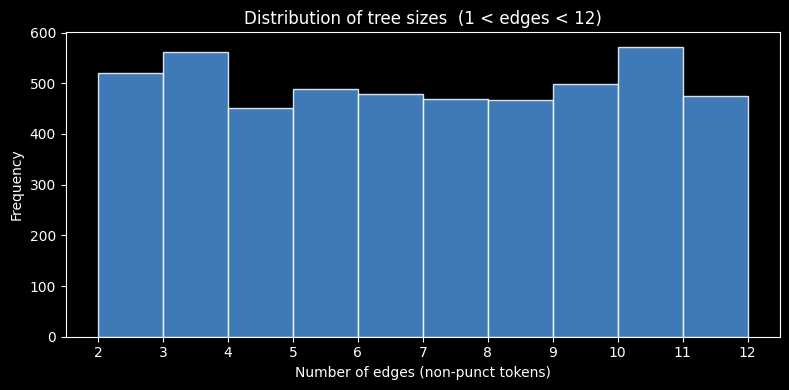

In [53]:
if all_records:
    edge_counts = [rec['n_edges'] for rec in all_records]

    print(f"Total sentences (1 < edges < {MAX_EDGES}) : {len(all_records)}")
    print(f"Min edge count                  : {min(edge_counts)}")
    print(f"Max edge count                  : {max(edge_counts)}")
    print(f"Mean edge count                 : {sum(edge_counts)/len(edge_counts):.2f}")

    # ── Per-file breakdown ──
    print(f"\n{'File':<50s}  {'Sentences':>10s}")
    print('-' * 62)
    for fpath, recs in corpus.items():
        print(f"{os.path.basename(fpath):<50s}  {len(recs):>10d}")

    # ── Histogram ──
    plt.figure(figsize=(8, 4))
    plt.hist(edge_counts, bins=range(2, MAX_EDGES + 1),
             edgecolor='white', color='#4A90D9', alpha=0.85)
    plt.xlabel('Number of edges (non-punct tokens)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of tree sizes  (1 < edges < {MAX_EDGES})')
    plt.xticks(range(2, MAX_EDGES + 1))
    plt.tight_layout()
    plt.show()
else:
    print("No trees loaded — check your CORPUS_DIR / INPUT_FILE path.")

---

## Step 2: Generate Random Baseline Trees

For each real dependency tree, we generate a **random baseline tree** that:
1. Has the **same number of nodes** (edges) as the real tree
2. Has the **same number of crossing (non-projective) edges**

This follows the algorithm in `baseline_conditions_random_structures.py`  
from the DLM-ICM-baselines repo:
- Generate a random **Prüfer code** of length `n`
- Decode it into an undirected tree
- Try all possible rootings → directed trees
- Pick one whose crossing count matches the real tree
- Add an abstract root node (id = 1000)
- Retry up to 40 000 times if no match is found

### 2.1  Prüfer code utilities (from `treegen.py`)

Re-implemented here without the `rfutils` dependency.

In [54]:
# ── Prüfer code → undirected tree (from treegen.py) ─────────────────

def random_pruefer_code(n: int) -> List[int]:
    """Generate a random Prüfer code of length n-2 for a tree with n nodes."""
    return [random.choice(range(n)) for _ in range(n - 2)]


def tree_edges_from_pruefer_code(code: List[int]):
    """Decode a Prüfer code into edges of an undirected tree."""
    code = list(code)
    l1 = set(range(len(code) + 2))
    edges = []
    while code and len(l1) > 2:
        x = min(l1.difference(code))
        edges.append((x, code[0]))
        l1.remove(x)
        code.pop(0)
    assert len(l1) == 2
    edges.append(tuple(l1))  # final edge between the two remaining nodes
    return edges


def tree_from_pruefer_code(code: List[int]) -> nx.Graph:
    """Create an undirected tree from a Prüfer code."""
    return nx.Graph(tree_edges_from_pruefer_code(code))


# ── Root an undirected tree at a given node → directed tree ─────────

def rooted_at(undirected_tree: nx.Graph, root_node: int) -> nx.DiGraph:
    """
    Given an undirected tree and a root node, return a directed tree
    (DiGraph) where all edges point away from the root (head → dependent).
    Uses BFS from root_node.
    """
    dtree = nx.DiGraph()
    dtree.add_nodes_from(undirected_tree.nodes())
    visited = {root_node}
    queue = [root_node]
    while queue:
        node = queue.pop(0)
        for neighbor in undirected_tree.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                dtree.add_edge(node, neighbor)  # head → dependent
                queue.append(neighbor)
    return dtree


def all_directed_trees(undirected_tree: nx.Graph) -> List[nx.DiGraph]:
    """Given an undirected tree, return all possible rooted directed trees."""
    return [rooted_at(undirected_tree, node)
            for node in undirected_tree.nodes()]


print("✓ Prüfer code utilities loaded.")

✓ Prüfer code utilities loaded.


### 2.2  Crossing (non-projectivity) counter

Counts the number of non-projective edges in a tree, following  
`Compute_measures.is_projective()` from the DLM-ICM-baselines `Measures.py`.

In [55]:
def is_projective_edge(tree: nx.DiGraph, edge: Tuple[int, int],
                       abstract_root: int) -> bool:
    """
    Check if a single edge (head, dep) in the tree is projective.

    An edge is projective iff every node linearly between head and dep
    is a descendant of the head (or its own head is inside the span).
    This mirrors Compute_measures.is_projective() from the reference code.
    """
    h, d = edge
    lo, hi = min(h, d), max(h, d)

    # Nodes linearly between head and dependent
    all_nodes = set(nx.descendants(tree, abstract_root))
    edge_span = [n for n in all_nodes if lo < n < hi]

    for nodeI in edge_span:
        node_head = tree.nodes[nodeI].get('head', None)
        if node_head is None:
            # For random trees without 'head' attr, find head via predecessors
            preds = list(tree.predecessors(nodeI))
            node_head = preds[0] if preds else abstract_root

        if node_head not in edge_span:
            if nodeI not in nx.descendants(tree, h):
                return False
    return True


def count_crossings(tree: nx.DiGraph, abstract_root: int) -> int:
    """Count the number of non-projective edges (excluding edges from abstract root)."""
    ncross = 0
    for edge in tree.edges:
        if edge[0] != abstract_root:
            if not is_projective_edge(tree, edge, abstract_root):
                ncross += 1
    return ncross


print("✓ Crossing counter loaded.")

✓ Crossing counter loaded.


### 2.3  Random baseline generator (from `baseline_conditions_random_structures.py`)

The `Random_base` class mirrors the reference code's approach:
1. Generate a random Prüfer code → undirected tree
2. Try all rootings → directed trees
3. Add abstract root (1000) and set `head` attributes
4. Accept if the crossing count matches the real tree
5. Retry up to `max_attempts` (40 000) times

In [56]:
ABSTRACT_ROOT = 1000   # same as reference code


class RandomBaselineGenerator:
    """
    Generates a random baseline tree that matches a real tree in:
      - number of nodes (edges)
      - number of crossing (non-projective) edges

    Mirrors `Random_base` from baseline_conditions_random_structures.py.
    """

    def __init__(self, real_tree: nx.DiGraph, real_root: int = 0):
        self.real_tree = real_tree
        self.real_root = real_root
        self.n_edges = len(real_tree.edges)

        # Count crossings in the real tree
        self.num_cross_real = count_crossings(real_tree, real_root)

    def _try_one(self) -> Optional[nx.DiGraph]:
        """
        Generate one random Prüfer-code tree, try all rootings.
        Return the first directed tree whose crossing count matches,
        or None if no rooting works.
        """
        n = self.n_edges  # number of edges = number of real nodes (excl. abstract root)
        code = random_pruefer_code(n)
        undirected = tree_from_pruefer_code(code)
        candidates = all_directed_trees(undirected)
        random.shuffle(candidates)

        for dtree in candidates:
            # Find the root of this directed tree
            real_root_node = next(nx.topological_sort(dtree))

            # Add abstract root (1000) → real root edge
            dtree.add_edge(ABSTRACT_ROOT, real_root_node)

            # Set 'head' attribute on every node (needed by crossing checker)
            for h, d in dtree.edges:
                dtree.nodes[d]['head'] = h

            # Check if crossings match
            ncross_rand = count_crossings(dtree, ABSTRACT_ROOT)
            if ncross_rand == self.num_cross_real:
                return dtree

            # Remove the abstract root edge before trying next rooting
            dtree.remove_edge(ABSTRACT_ROOT, real_root_node)
            if ABSTRACT_ROOT in dtree.nodes:
                dtree.remove_node(ABSTRACT_ROOT)

        return None

    def generate(self, max_attempts: int = 40000) -> Optional[nx.DiGraph]:
        """
        Try up to max_attempts Prüfer codes to find a matching random tree.

        Returns
        -------
        nx.DiGraph or None
            A random directed tree with abstract root = 1000,
            matching the real tree in node count and crossing count.
        """
        for _ in range(max_attempts):
            result = self._try_one()
            if result is not None:
                return result
        return None  # could not find a match


print("✓ RandomBaselineGenerator loaded.")

✓ RandomBaselineGenerator loaded.


### 2.4  Generate random baselines for all extracted trees

For each real tree in `all_records`, we generate one random baseline.  
Results are stored in `all_records[i]['random_tree']`.

In [57]:
import os
import time
import pickle

OUTPUT_FILE = "CGS410_trees_with_baselines_english.pkl"

# SMART CHECK: If the pkl file already exists, just load it
if os.path.exists(OUTPUT_FILE):
    print(f"✅ Found existing data file: {OUTPUT_FILE}")
    print("Skipping heavy random graph generation...")
    
    with open(OUTPUT_FILE, 'rb') as f:
        all_records = pickle.load(f)
    
    print(f"Loaded {len(all_records)} trees instantly!")

else:
    # FILE DOES NOT EXIST: We need to do the math.
    print(f"No existing data file found. Generating random baselines...")
    success_count = 0
    fail_count = 0
    t0 = time.time()

    for i, rec in enumerate(all_records):
        gen = RandomBaselineGenerator(rec['tree'], real_root=0)
        rand_tree = gen.generate(max_attempts=40000)

        rec['random_tree'] = rand_tree
        rec['num_cross_real'] = gen.num_cross_real

        if rand_tree is not None:
            success_count += 1
        else:
            fail_count += 1

        if (i + 1) % 500 == 0:
            elapsed = time.time() - t0
            print(f"  [{i+1}/{len(all_records)}]  success={success_count}  fail={fail_count}  ({elapsed:.1f}s)")

    elapsed = time.time() - t0
    print(f"\n── Generation complete! ({elapsed:.1f}s) ──")
    print(f"   Success: {success_count} | Failures: {fail_count}")

    # Immediately save the data
    with open(OUTPUT_FILE, 'wb') as f:
        pickle.dump(all_records, f)
    print(f"✅ Saved {len(all_records)} records to {OUTPUT_FILE}")
    
    import pickle
    import os
    import time

    OUTPUT_FILE = "CGS410_trees_with_baselines_english.pkl"

    # 1. SAVE WHAT WE HAVE SO FAR JUST IN CASE
    with open(OUTPUT_FILE, 'wb') as f:
        pickle.dump(all_records, f)
    print(f"✅ Successfully saved your current {len(all_records)} records to {OUTPUT_FILE} (Safe to close Jupyter at any time).")

    # 2. ISOLATE THE FAILED ONES
    failed_records = [rec for rec in all_records if rec.get('random_tree') is None]

    if not failed_records:
        print("No failed records to retry!")
    else:
        print(f"\nRetrying {len(failed_records)} failed sentences with the full 40,000 maximum attempts...")
        success_count = 0
        fail_count = 0
        t0 = time.time()
        
        for i, rec in enumerate(failed_records):
            gen = RandomBaselineGenerator(rec['tree'], real_root=0)
            
            # Heavy 40,000 limit retry loop
            rand_tree = gen.generate(max_attempts=40000)
            
            # Update the original record in memory
            rec['random_tree'] = rand_tree
            rec['num_cross_real'] = gen.num_cross_real
            
            if rand_tree is not None:
                success_count += 1
            else:
                fail_count += 1
                
            if (i + 1) % 50 == 0:
                elapsed = time.time() - t0
                print(f"  [{i+1}/{len(failed_records)}]  success={success_count}  fail={fail_count}  ({elapsed:.1f}s)")

        elapsed = time.time() - t0
        print(f"\n── Done retrying in {elapsed:.1f}s ──")
        print(f"   Newly recovered random graphs: {success_count}")
        print(f"   Mathematically Too Difficult (Still Failed): {fail_count}")
        
        # 3. SAVE THE UPDATED RESULTS
        with open(OUTPUT_FILE, 'wb') as f:
            pickle.dump(all_records, f)
        print(f"✅ Automatically updated {OUTPUT_FILE} with the new results!")




✅ Found existing data file: CGS410_trees_with_baselines_english.pkl
Skipping heavy random graph generation...
Loaded 4982 trees instantly!


### 2.5  Inspect a real tree vs. its random baseline

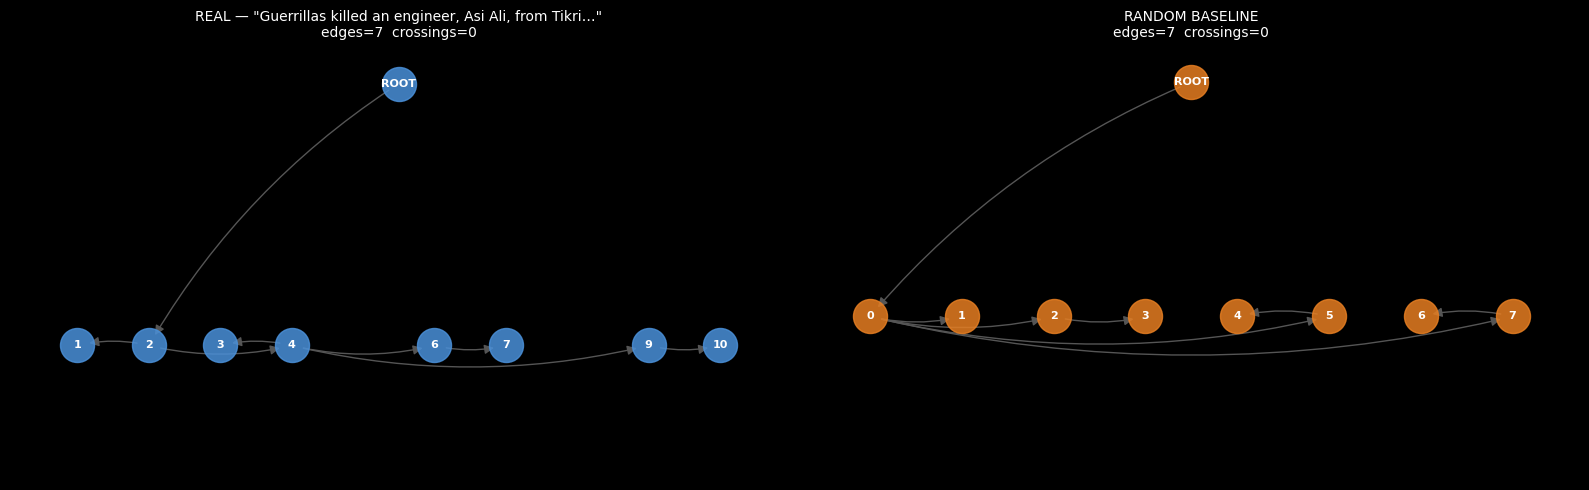

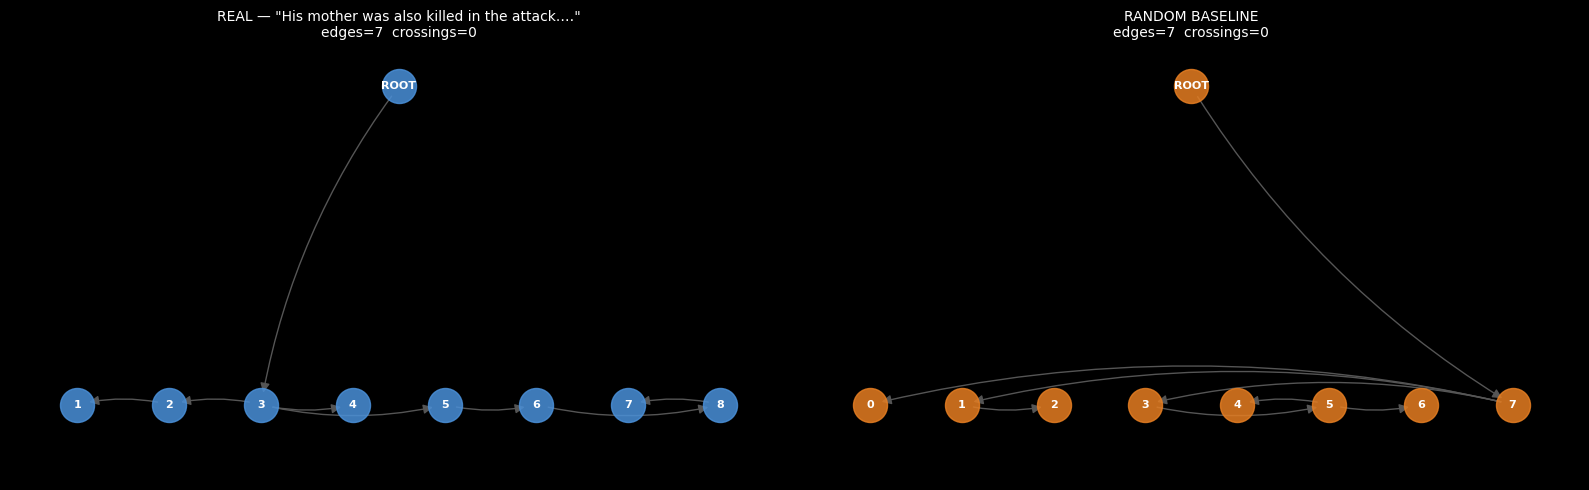

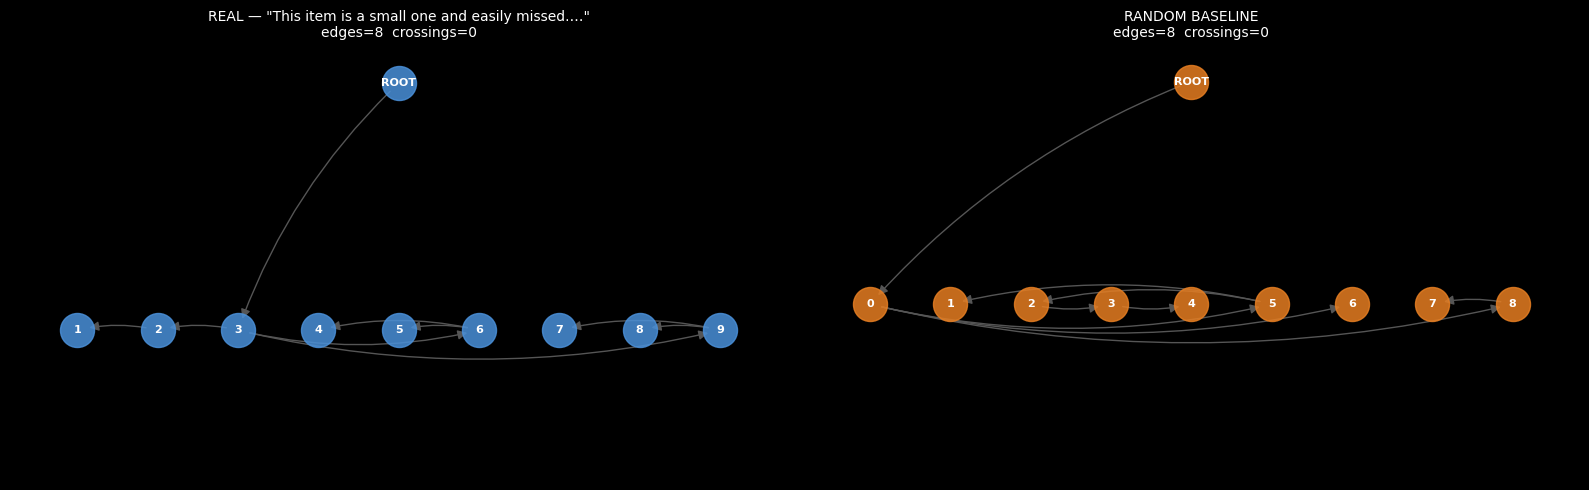

In [58]:
def compare_trees(rec: Dict, figsize: Tuple = (16, 5)):
    """Plot a real tree and its random baseline side by side."""
    real_tree = rec['tree']
    rand_tree = rec.get('random_tree')

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ── Helper to draw one tree ──
    def draw(ax, tree, title, abstract_root, color):
        non_root = sorted(n for n in tree.nodes if n != abstract_root)
        if non_root:
            mid = (non_root[0] + non_root[-1]) / 2
        else:
            mid = 0
        pos = {abstract_root: (mid, 1)}
        for n in non_root:
            pos[n] = (n, 0)

        labels = {abstract_root: 'ROOT'}
        for n in non_root:
            labels[n] = str(n)

        nx.draw_networkx_nodes(tree, pos, node_color=color,
                               node_size=600, alpha=0.85, ax=ax)
        nx.draw_networkx_labels(tree, pos, labels, font_size=8,
                                font_weight='bold', font_color='white', ax=ax)
        nx.draw_networkx_edges(tree, pos, edge_color='#555',
                               arrows=True, arrowsize=14,
                               connectionstyle='arc3,rad=0.12', ax=ax)
        ncross = count_crossings(tree, abstract_root)
        ax.set_title(f"{title}\nedges={len(tree.edges)-1}  crossings={ncross}",
                     fontsize=10, pad=10)
        ax.axis('off')

    # ── Real tree ──
    draw(axes[0], real_tree, f"REAL — \"{rec['text'][:50]}…\"", 0, '#4A90D9')

    # ── Random tree ──
    if rand_tree is not None:
        draw(axes[1], rand_tree, "RANDOM BASELINE", ABSTRACT_ROOT, '#E67E22')
    else:
        axes[1].text(0.5, 0.5, 'No random tree generated\n(no crossing match found)',
                     ha='center', va='center', fontsize=12, color='gray')
        axes[1].set_title('RANDOM BASELINE', fontsize=10)
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()
# ── Show first 3 examples ──
for rec in all_records[:3]:
    compare_trees(rec)

### 2.6  Random baseline generation statistics

Total real trees           : 4982
With random baseline       : 4982
Without random baseline    : 0

Crossing counts (real trees with baselines):
  0 crossings (projective): 4879
  1+ crossings:             103


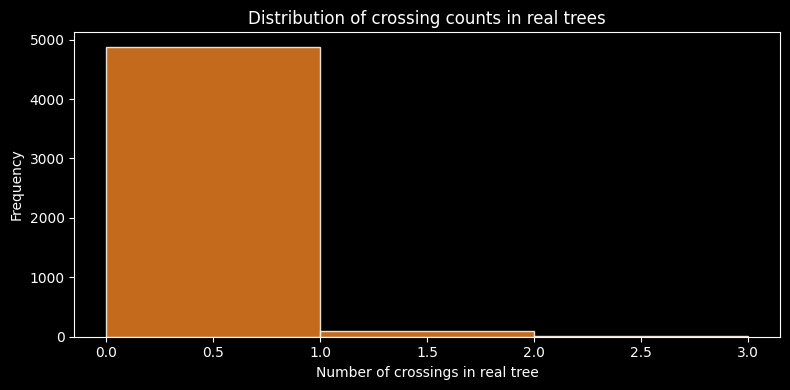

In [59]:
# ── Summary ──
has_random = [rec for rec in all_records if rec.get('random_tree') is not None]
no_random  = [rec for rec in all_records if rec.get('random_tree') is None]

print(f"Total real trees           : {len(all_records)}")
print(f"With random baseline       : {len(has_random)}")
print(f"Without random baseline    : {len(no_random)}")

if has_random:
    crossing_counts = [rec['num_cross_real'] for rec in has_random]
    print(f"\nCrossing counts (real trees with baselines):")
    print(f"  0 crossings (projective): {crossing_counts.count(0)}")
    print(f"  1+ crossings:             {sum(1 for c in crossing_counts if c > 0)}")

    # Histogram of crossing counts
    plt.figure(figsize=(8, 4))
    plt.hist(crossing_counts,
             bins=range(0, max(crossing_counts) + 2),
             edgecolor='white', color='#E67E22', alpha=0.85)
    plt.xlabel('Number of crossings in real tree')
    plt.ylabel('Frequency')
    plt.title('Distribution of crossing counts in real trees')
    plt.tight_layout()
    plt.show()

---

The real trees and their matching random baselines are now stored in `all_records`.  
Each record has:
- `rec['tree']` — the real dependency tree (`nx.DiGraph`, root = 0)
- `rec['random_tree']` — the random baseline (`nx.DiGraph`, root = 1000) or `None`
- `rec['num_cross_real']` — crossing count of the real tree

**Next steps:** Feature extraction, time-series tracking (Active Memory Burden),  
and ML classification.

---

## Step 3: Feature Extraction & Comparative Visualization

We extract a **7-parameter feature set** for both **real** and **random baseline** trees, then visualize each property's distribution.

| # | Feature | Description |
|---|---------|-------------|
| 3.1 | Maximum Arity | Highest out-degree (children) of any node |
| 3.2 | Average Arity | Mean out-degree across all nodes |
| 3.3 | Maximum Depth | Longest root-to-leaf path |
| 3.4 | Graph Density | `nx.density()` — identical for same-size trees |
| 3.5 | Average Intervener Complexity (ICM) | Avg. intervening heads per edge |
| 3.6 | Average Dependency Length (DLM) | Avg. linear distance per edge |
| 3.7 | Edge Directionality (L→R %) | Fraction of left-to-right edges |
| 3.8 | Crossing Dependencies | Non-projective edge count (constrained equal) |

In [60]:
import numpy as np

# ── Universal feature extractor ──
def get_tree_features(tree: nx.DiGraph, root: int, ncross: int):
    """Extract all 8 graph parameters from a single tree."""
    out_degrees = [d for n, d in tree.out_degree() if n != root]
    max_arity = max(out_degrees) if out_degrees else 0
    avg_arity = np.mean(out_degrees) if out_degrees else 0
    
    lengths = nx.shortest_path_length(tree, root)
    max_depth = max(lengths.values()) if lengths else 0
    
    graph_density = nx.density(tree)
    
    ic_list, dl_list = [], []
    lr_edges = 0
    valid_edges = 0
    
    for u, v in tree.edges():
        if u == root: continue
        valid_edges += 1
        if u < v: lr_edges += 1
        lower, upper = min(u, v), max(u, v)
        ic = 1
        dl = 0
        for nodex in tree.nodes():
            if nodex == root: continue
            if lower < nodex < upper:
                dl += 1
                if tree.out_degree(nodex) > 0:
                    ic += 1
        ic_list.append(ic)
        dl_list.append(dl)
    
    avg_ic = np.mean(ic_list) if ic_list else 0
    avg_dl = np.mean(dl_list) if dl_list else 0
    directionality = lr_edges / valid_edges if valid_edges > 0 else 0
    
    return [max_arity, avg_arity, max_depth, graph_density, avg_ic, avg_dl, directionality, ncross]

# ── Extract features for ALL valid pairs ──
real_features = []
rand_features = []

print("Extracting features for all valid tree pairs...")
for rec in all_records:
    real_tree = rec.get('tree')
    random_tree = rec.get('random_tree')
    if random_tree is not None:
        cross = rec.get('num_cross_real', 0)
        real_features.append(get_tree_features(real_tree, root=0, ncross=cross))
        rand_features.append(get_tree_features(random_tree, root=1000, ncross=cross))

real_features = np.array(real_features)
rand_features = np.array(rand_features)
print(f"Extracted 8 features across {len(real_features)} sentence pairs!")

Extracting features for all valid tree pairs...
Extracted 8 features across 4982 sentence pairs!


### 3.1  Maximum Arity


=== Maximum Arity ===
  Real   -> mean: 2.4117, std: 0.9960
  Random -> mean: 2.3348, std: 1.0082


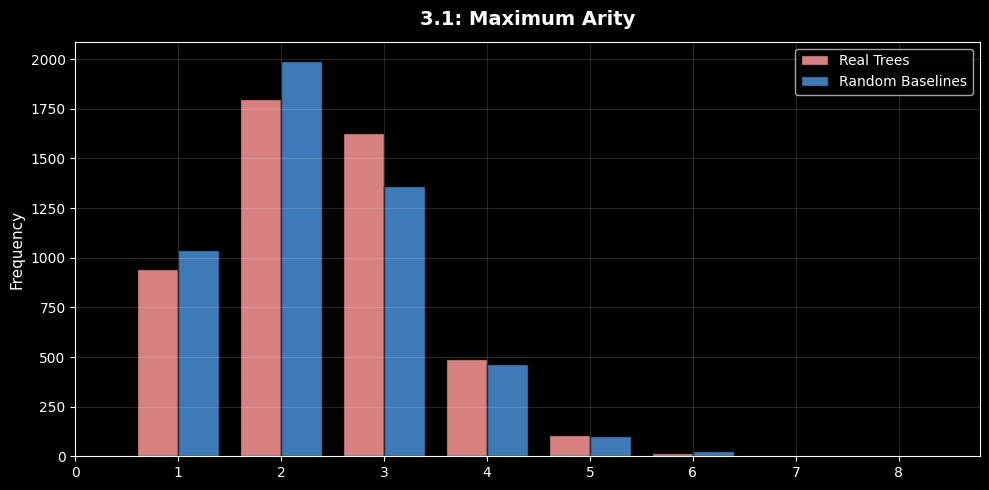

In [61]:
# ── 3.1: Maximum Arity ──
idx = 0
data_real = real_features[:, idx]
data_rand = rand_features[:, idx]

print(f"=== Maximum Arity ===")
print(f"  Real   -> mean: {np.mean(data_real):.4f}, std: {np.std(data_real):.4f}")
print(f"  Random -> mean: {np.mean(data_rand):.4f}, std: {np.std(data_rand):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))

if len(np.unique(data_real)) < 20 and len(np.unique(data_rand)) < 20:
    max_val = int(max(np.max(data_real), np.max(data_rand)))
    bins = np.arange(np.min([np.min(data_real), np.min(data_rand)]), max_val + 2) - 0.5
    ax.hist([data_real, data_rand], bins=bins, color=['#FF9999', '#4A90D9'],
            label=['Real Trees', 'Random Baselines'], edgecolor='black', alpha=0.85)
    ax.set_xticks(range(int(np.min(bins)), max_val + 1))
else:
    bins = 30
    ax.hist(data_real, bins=bins, color='#FF9999', alpha=0.6, label='Real Trees')
    ax.hist(data_rand, bins=bins, color='#4A90D9', alpha=0.6, label='Random Baselines')

ax.set_title('3.1: Maximum Arity', fontsize=14, pad=12, weight='bold')
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

### 3.2  Average Arity


=== Average Arity ===
  Real   -> mean: 0.7955, std: 0.1250
  Random -> mean: 0.7955, std: 0.1250


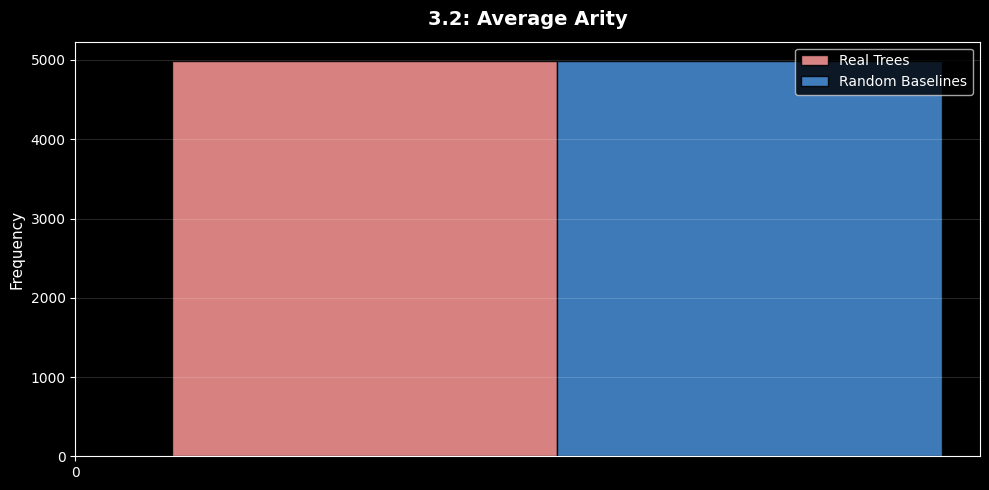

In [62]:
# ── 3.2: Average Arity ──
idx = 1
data_real = real_features[:, idx]
data_rand = rand_features[:, idx]

print(f"=== Average Arity ===")
print(f"  Real   -> mean: {np.mean(data_real):.4f}, std: {np.std(data_real):.4f}")
print(f"  Random -> mean: {np.mean(data_rand):.4f}, std: {np.std(data_rand):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))

if len(np.unique(data_real)) < 20 and len(np.unique(data_rand)) < 20:
    max_val = int(max(np.max(data_real), np.max(data_rand)))
    bins = np.arange(np.min([np.min(data_real), np.min(data_rand)]), max_val + 2) - 0.5
    ax.hist([data_real, data_rand], bins=bins, color=['#FF9999', '#4A90D9'],
            label=['Real Trees', 'Random Baselines'], edgecolor='black', alpha=0.85)
    ax.set_xticks(range(int(np.min(bins)), max_val + 1))
else:
    bins = 30
    ax.hist(data_real, bins=bins, color='#FF9999', alpha=0.6, label='Real Trees')
    ax.hist(data_rand, bins=bins, color='#4A90D9', alpha=0.6, label='Random Baselines')

ax.set_title('3.2: Average Arity', fontsize=14, pad=12, weight='bold')
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

### 3.3  Maximum Depth


=== Maximum Depth ===
  Real   -> mean: 3.9635, std: 1.4742
  Random -> mean: 4.1026, std: 1.5133


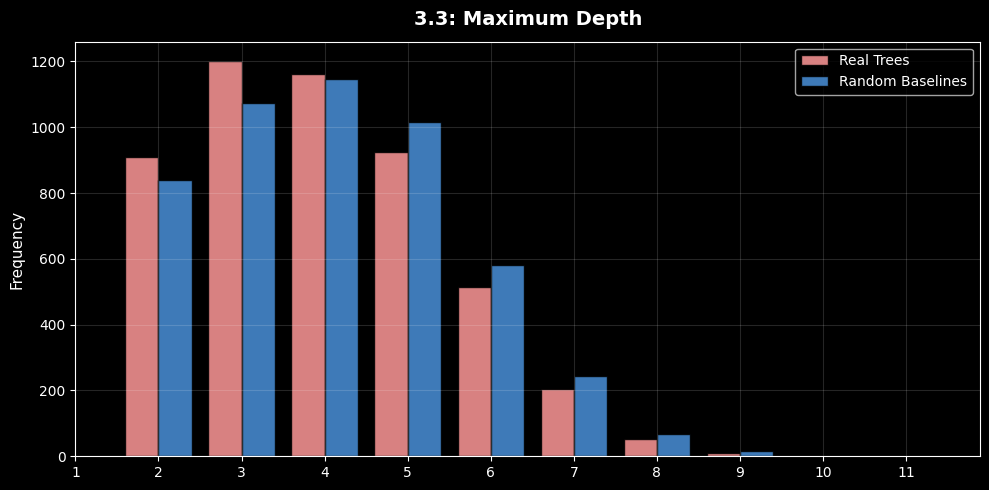

In [63]:
# ── 3.3: Maximum Depth ──
idx = 2
data_real = real_features[:, idx]
data_rand = rand_features[:, idx]

print(f"=== Maximum Depth ===")
print(f"  Real   -> mean: {np.mean(data_real):.4f}, std: {np.std(data_real):.4f}")
print(f"  Random -> mean: {np.mean(data_rand):.4f}, std: {np.std(data_rand):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))

if len(np.unique(data_real)) < 20 and len(np.unique(data_rand)) < 20:
    max_val = int(max(np.max(data_real), np.max(data_rand)))
    bins = np.arange(np.min([np.min(data_real), np.min(data_rand)]), max_val + 2) - 0.5
    ax.hist([data_real, data_rand], bins=bins, color=['#FF9999', '#4A90D9'],
            label=['Real Trees', 'Random Baselines'], edgecolor='black', alpha=0.85)
    ax.set_xticks(range(int(np.min(bins)), max_val + 1))
else:
    bins = 30
    ax.hist(data_real, bins=bins, color='#FF9999', alpha=0.6, label='Real Trees')
    ax.hist(data_rand, bins=bins, color='#4A90D9', alpha=0.6, label='Random Baselines')

ax.set_title('3.3: Maximum Depth', fontsize=14, pad=12, weight='bold')
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

### 3.4  Graph Density


=== Graph Density ===
  Real   -> mean: 0.1618, std: 0.0777
  Random -> mean: 0.1618, std: 0.0777


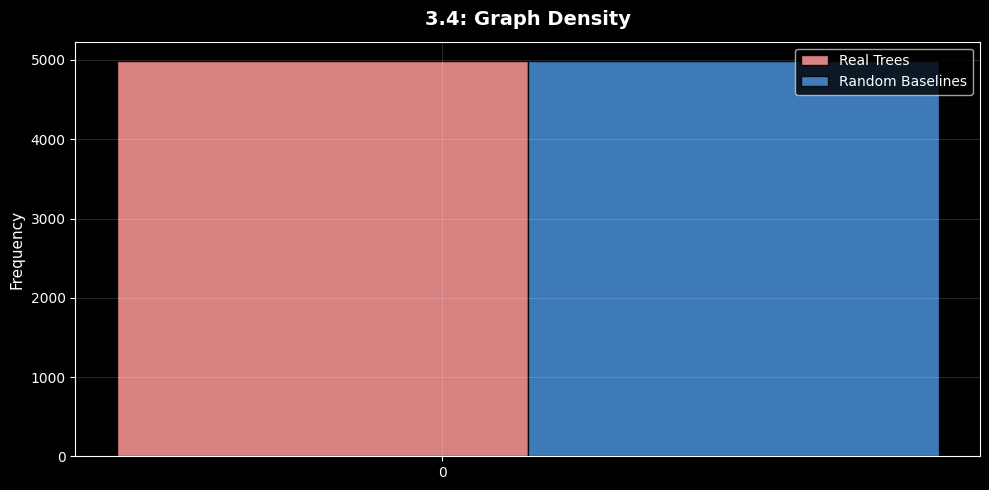

In [64]:
# ── 3.4: Graph Density ──
idx = 3
data_real = real_features[:, idx]
data_rand = rand_features[:, idx]

print(f"=== Graph Density ===")
print(f"  Real   -> mean: {np.mean(data_real):.4f}, std: {np.std(data_real):.4f}")
print(f"  Random -> mean: {np.mean(data_rand):.4f}, std: {np.std(data_rand):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))

if len(np.unique(data_real)) < 20 and len(np.unique(data_rand)) < 20:
    max_val = int(max(np.max(data_real), np.max(data_rand)))
    bins = np.arange(np.min([np.min(data_real), np.min(data_rand)]), max_val + 2) - 0.5
    ax.hist([data_real, data_rand], bins=bins, color=['#FF9999', '#4A90D9'],
            label=['Real Trees', 'Random Baselines'], edgecolor='black', alpha=0.85)
    ax.set_xticks(range(int(np.min(bins)), max_val + 1))
else:
    bins = 30
    ax.hist(data_real, bins=bins, color='#FF9999', alpha=0.6, label='Real Trees')
    ax.hist(data_rand, bins=bins, color='#4A90D9', alpha=0.6, label='Random Baselines')

ax.set_title('3.4: Graph Density', fontsize=14, pad=12, weight='bold')
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

### 3.5  Average Intervener Complexity


=== Average Intervener Complexity ===
  Real   -> mean: 1.1023, std: 0.1749
  Random -> mean: 1.3843, std: 0.4049


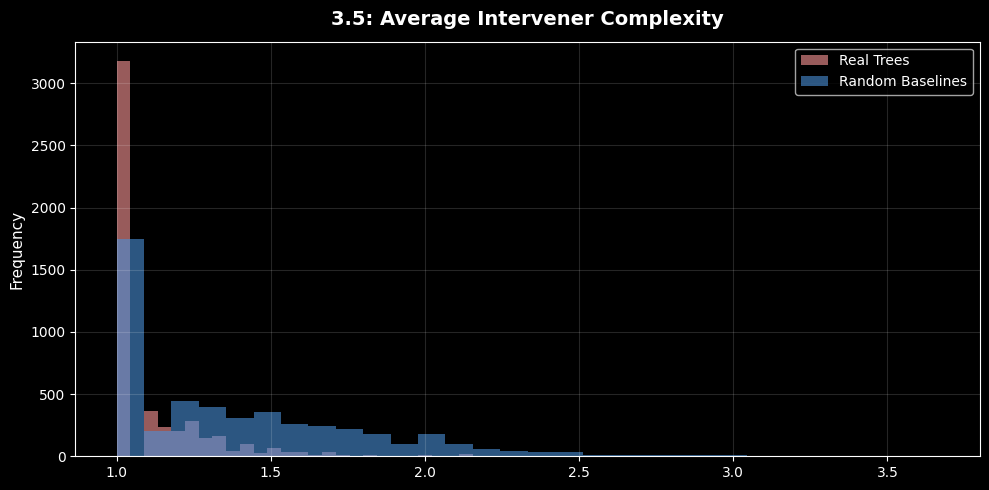

In [65]:
# ── 3.5: Average Intervener Complexity ──
idx = 4
data_real = real_features[:, idx]
data_rand = rand_features[:, idx]

print(f"=== Average Intervener Complexity ===")
print(f"  Real   -> mean: {np.mean(data_real):.4f}, std: {np.std(data_real):.4f}")
print(f"  Random -> mean: {np.mean(data_rand):.4f}, std: {np.std(data_rand):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))

if len(np.unique(data_real)) < 20 and len(np.unique(data_rand)) < 20:
    max_val = int(max(np.max(data_real), np.max(data_rand)))
    bins = np.arange(np.min([np.min(data_real), np.min(data_rand)]), max_val + 2) - 0.5
    ax.hist([data_real, data_rand], bins=bins, color=['#FF9999', '#4A90D9'],
            label=['Real Trees', 'Random Baselines'], edgecolor='black', alpha=0.85)
    ax.set_xticks(range(int(np.min(bins)), max_val + 1))
else:
    bins = 30
    ax.hist(data_real, bins=bins, color='#FF9999', alpha=0.6, label='Real Trees')
    ax.hist(data_rand, bins=bins, color='#4A90D9', alpha=0.6, label='Random Baselines')

ax.set_title('3.5: Average Intervener Complexity', fontsize=14, pad=12, weight='bold')
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

### 3.6  Average Dependency Length


=== Average Dependency Length ===
  Real   -> mean: 0.5238, std: 0.4334
  Random -> mean: 1.0882, std: 0.7905


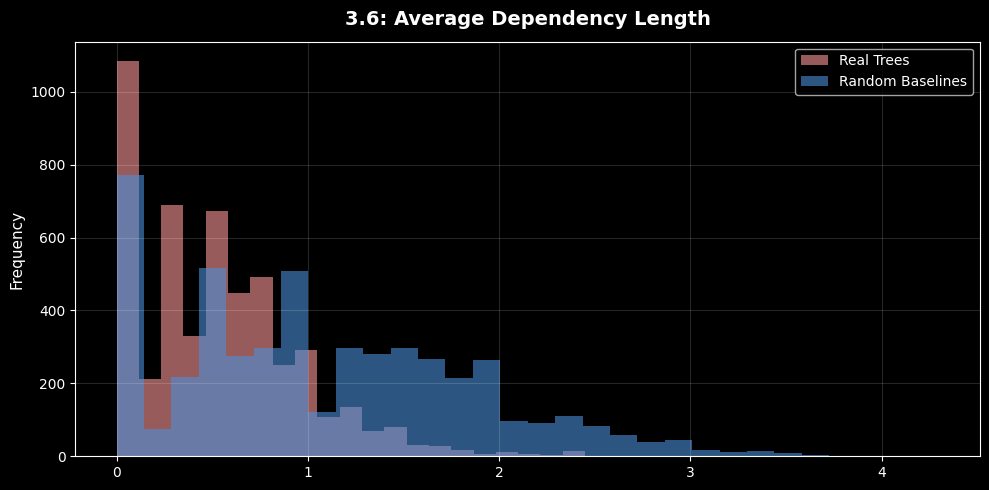

In [66]:
# ── 3.6: Average Dependency Length ──
idx = 5
data_real = real_features[:, idx]
data_rand = rand_features[:, idx]

print(f"=== Average Dependency Length ===")
print(f"  Real   -> mean: {np.mean(data_real):.4f}, std: {np.std(data_real):.4f}")
print(f"  Random -> mean: {np.mean(data_rand):.4f}, std: {np.std(data_rand):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))

if len(np.unique(data_real)) < 20 and len(np.unique(data_rand)) < 20:
    max_val = int(max(np.max(data_real), np.max(data_rand)))
    bins = np.arange(np.min([np.min(data_real), np.min(data_rand)]), max_val + 2) - 0.5
    ax.hist([data_real, data_rand], bins=bins, color=['#FF9999', '#4A90D9'],
            label=['Real Trees', 'Random Baselines'], edgecolor='black', alpha=0.85)
    ax.set_xticks(range(int(np.min(bins)), max_val + 1))
else:
    bins = 30
    ax.hist(data_real, bins=bins, color='#FF9999', alpha=0.6, label='Real Trees')
    ax.hist(data_rand, bins=bins, color='#4A90D9', alpha=0.6, label='Random Baselines')

ax.set_title('3.6: Average Dependency Length', fontsize=14, pad=12, weight='bold')
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

### 3.7  Edge Directionality (L-R Ratio)


=== Edge Directionality (L-R Ratio) ===
  Real   -> mean: 0.5798, std: 0.2711
  Random -> mean: 0.5003, std: 0.2930


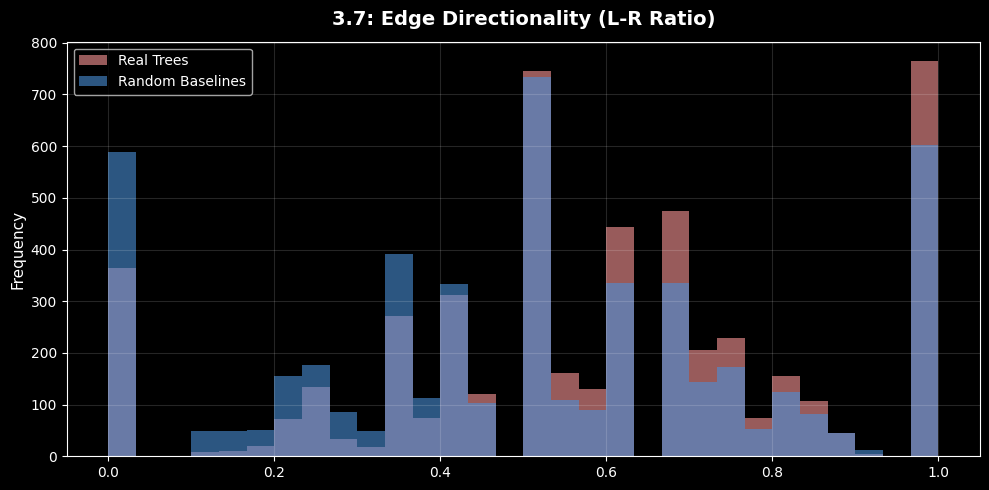

In [67]:
# ── 3.7: Edge Directionality (L-R Ratio) ──
idx = 6
data_real = real_features[:, idx]
data_rand = rand_features[:, idx]

print(f"=== Edge Directionality (L-R Ratio) ===")
print(f"  Real   -> mean: {np.mean(data_real):.4f}, std: {np.std(data_real):.4f}")
print(f"  Random -> mean: {np.mean(data_rand):.4f}, std: {np.std(data_rand):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))

if len(np.unique(data_real)) < 20 and len(np.unique(data_rand)) < 20:
    max_val = int(max(np.max(data_real), np.max(data_rand)))
    bins = np.arange(np.min([np.min(data_real), np.min(data_rand)]), max_val + 2) - 0.5
    ax.hist([data_real, data_rand], bins=bins, color=['#FF9999', '#4A90D9'],
            label=['Real Trees', 'Random Baselines'], edgecolor='black', alpha=0.85)
    ax.set_xticks(range(int(np.min(bins)), max_val + 1))
else:
    bins = 30
    ax.hist(data_real, bins=bins, color='#FF9999', alpha=0.6, label='Real Trees')
    ax.hist(data_rand, bins=bins, color='#4A90D9', alpha=0.6, label='Random Baselines')

ax.set_title('3.7: Edge Directionality (L-R Ratio)', fontsize=14, pad=12, weight='bold')
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

### 3.8  Crossing Dependencies


=== Crossing Dependencies ===
  Real   -> mean: 0.0221, std: 0.1562
  Random -> mean: 0.0221, std: 0.1562


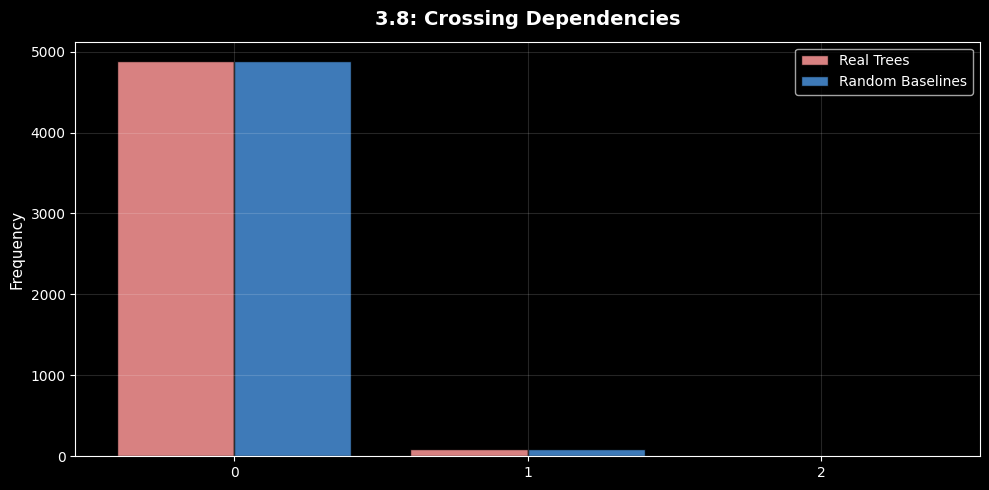

: 

In [ ]:
# ── 3.8: Crossing Dependencies ──
idx = 7
data_real = real_features[:, idx]
data_rand = rand_features[:, idx]

print(f"=== Crossing Dependencies ===")
print(f"  Real   -> mean: {np.mean(data_real):.4f}, std: {np.std(data_real):.4f}")
print(f"  Random -> mean: {np.mean(data_rand):.4f}, std: {np.std(data_rand):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))

if len(np.unique(data_real)) < 20 and len(np.unique(data_rand)) < 20:
    max_val = int(max(np.max(data_real), np.max(data_rand)))
    bins = np.arange(np.min([np.min(data_real), np.min(data_rand)]), max_val + 2) - 0.5
    ax.hist([data_real, data_rand], bins=bins, color=['#FF9999', '#4A90D9'],
            label=['Real Trees', 'Random Baselines'], edgecolor='black', alpha=0.85)
    ax.set_xticks(range(int(np.min(bins)), max_val + 1))
else:
    bins = 30
    ax.hist(data_real, bins=bins, color='#FF9999', alpha=0.6, label='Real Trees')
    ax.hist(data_rand, bins=bins, color='#4A90D9', alpha=0.6, label='Random Baselines')

ax.set_title('3.8: Crossing Dependencies', fontsize=14, pad=12, weight='bold')
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()